In [1]:
# ============================================================
# Regresión Logística simple con adult.csv
# ============================================================

# 1. Importar librerías necesarias para cargar datos, entrenar el modelo y evaluar resultados.
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

In [2]:
# 2. Cargar el archivo CSV.
df = pd.read_csv("adult.csv")


# 3. Revisar rápidamente el tamaño del dataset y las primeras filas.
print("Tamaño del dataset:", df.shape)
print(df.head())

Tamaño del dataset: (32561, 16)
   age workclass  fnlwgt education  education-num marital-status  \
0   17       NaN  304873      10th              6  Never-married   
1   17   Private   65368      11th              7  Never-married   
2   17   Private  245918      11th              7  Never-married   
3   17   Private  191260       9th              5  Never-married   
4   17   Private  270942   5th-6th              3  Never-married   

      occupation    relationship   race     sex  capital-gain  capital-loss  \
0            NaN       Own-child  White  Female         34095             0   
1          Sales       Own-child  White  Female             0             0   
2  Other-service       Own-child  White    Male             0             0   
3  Other-service       Own-child  White    Male          1055             0   
4  Other-service  Other-relative  White    Male             0             0   

   hours-per-week native-country     age-bin income  
0              32  United-Stat

In [3]:
# 4. Definir la variable objetivo que queremos predecir.
target = "income"

In [4]:
# 5. Separar las variables predictoras X y la variable objetivo y.
X = df.drop(columns=[target])
y = df[target]

In [5]:
# 6. Convertir la variable objetivo en valores numéricos: <=50K = 0 y >50K = 1.
y = y.map({"<=50K": 0, ">50K": 1})

In [6]:
# 7. Identificar columnas numéricas y categóricas para tratarlas de forma diferente.
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns


In [7]:
# 8. Rellenar valores faltantes numéricos usando la mediana de cada columna.
for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())

In [8]:
# 9. Rellenar valores faltantes categóricos usando la moda de cada columna.
for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

In [9]:
# 10. Convertir variables categóricas en variables dummy para que la regresión logística pueda usarlas.
X_encoded = pd.get_dummies(X, drop_first=True)

In [10]:
# 11. Dividir los datos en entrenamiento y prueba después de preparar las variables.
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
# 12. Escalar los datos para que la regresión logística trabaje mejor con variables en diferentes escalas.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# 13. Crear el modelo de Regresión Logística.
model = LogisticRegression(max_iter=1000)

In [13]:
# 14. Entrenar el modelo usando únicamente los datos de entrenamiento.
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [14]:
# 15. Generar predicciones sobre el conjunto de prueba.
y_pred = model.predict(X_test_scaled)

# 16. Generar probabilidades para evaluar la capacidad del modelo de separar las clases.
y_prob = model.predict_proba(X_test_scaled)[:, 1]


In [15]:
# 17. Evaluar el modelo usando Accuracy, Matriz de Confusión, Classification Report y AUC.
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("\nResultados del modelo:")
print("Accuracy:", round(accuracy, 4))
print("AUC:", round(auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Resultados del modelo:
Accuracy: 0.8511
AUC: 0.9068

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      4945
           1       0.73      0.61      0.66      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.78      6513
weighted avg       0.84      0.85      0.85      6513



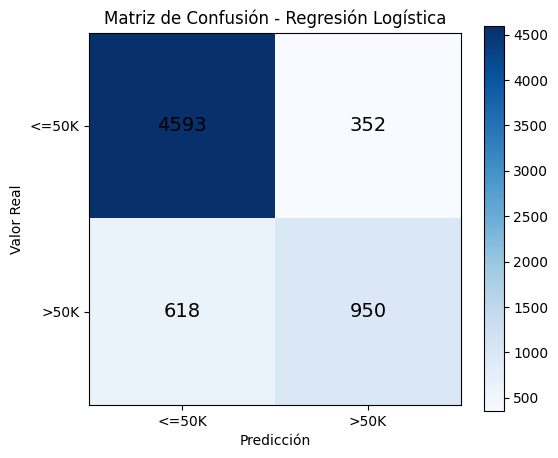

In [25]:
# 18. Crear y mostrar la matriz de confusión.
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Valor Real")
plt.colorbar()

plt.xticks([0, 1], ["<=50K", ">50K"])
plt.yticks([0, 1], ["<=50K", ">50K"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

plt.show()

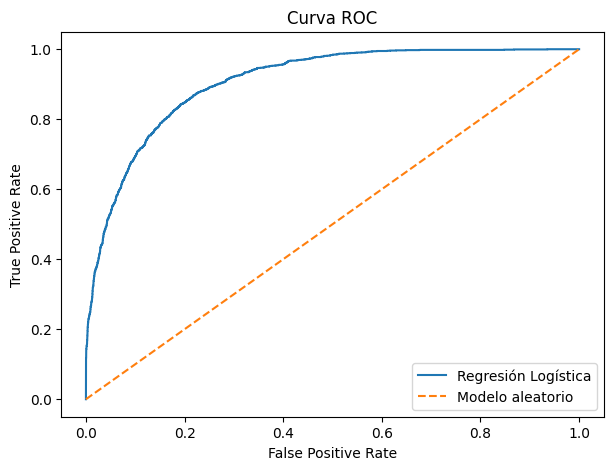

In [26]:
# 19. Crear y mostrar la curva ROC para visualizar el desempeño del modelo.
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Regresión Logística")
plt.plot([0, 1], [0, 1], linestyle="--", label="Modelo aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.show()

In [27]:
# 20. Mostrar algunos ejemplos comparando el valor real, la predicción y la probabilidad estimada.
results = pd.DataFrame({
    "Income real": y_test.values,
    "Income predicho": y_pred,
    "Probabilidad >50K": y_prob
})

print("\nPrimeras predicciones:")
print(results.head(10))


Primeras predicciones:
   Income real  Income predicho  Probabilidad >50K
0            0                0           0.292130
1            0                0           0.036849
2            1                1           0.686726
3            1                1           0.990911
4            0                0           0.060486
5            0                0           0.003287
6            0                0           0.098958
7            0                0           0.011224
8            0                0           0.024666
9            0                0           0.037027
